# ML-09 — Validation and Research Claim Audit

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Two paper findings + methodology questions

**Finding 1:** combining multiple search signals can improve content
opportunity identification. *Question:* was the label based on future
performance, manual review, or a rule — and were the label-defining fields
also used as model inputs?

**Finding 2:** a machine learning model outperformed simpler approaches.
*Question:* was validation grouped/time-aware, and was the reported
accuracy sanity-checked against how many distinct groups the test set
actually contained?

In [1]:
import pandas as pd
import numpy as np

from google.colab import userdata
from datasets import load_dataset

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

HF_TOKEN = userdata.get("HF_TOKEN")

ds = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    token=HF_TOKEN
)

# FIX #4: shuffle before sampling.
sample = ds["train"].shuffle(seed=42).select(range(10000)).to_pandas()
sample = sample.fillna(0)

n_unique_clients = sample["client_hash_id"].nunique()
print(sample.shape)
print("Unique clients in sample:", n_unique_clients)

assert n_unique_clients >= 20, (
    f"Only {n_unique_clients} clients in the sample — grouped validation "
    f"would not be meaningful. Check upstream sampling."
)

README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 4.41MB            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 89.0MB            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 8.93MB            

...

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/78835655 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/39 [00:00<?, ?it/s]

(10000, 30)
Unique clients in sample: 69


## 2. Target + audited features — same leakage fix as W05

In [2]:
TARGET_DEFINING_FIELDS = ["gsc_avg_position", "gsc_clicks"]

sample["target"] = (
    (sample["gsc_avg_position"] > 20) &
    (sample["gsc_clicks"] < 5)
).astype(int)

candidate_features = [
    "gsc_impressions", "gsc_clicks", "gsc_avg_position",
    "ga4_pageviews", "ga4_sessions", "ga4_users", "ga4_engaged_sessions",
    "sessions_organic", "sessions_direct", "sessions_referral",
    "sessions_social", "sessions_paid", "sessions_ai", "scroll_events"
]

# FIX #1: programmatically exclude target-defining fields.
features = [f for f in candidate_features if f not in TARGET_DEFINING_FIELDS]
print("Removed as target-defining:", [f for f in candidate_features if f in TARGET_DEFINING_FIELDS])
print("Final feature list:", features)

X = sample[features]
y = sample["target"]

Removed as target-defining: ['gsc_clicks', 'gsc_avg_position']
Final feature list: ['gsc_impressions', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'scroll_events']


## 3. Before vs after: random split vs grouped split (now on the leakage-fixed features)

In [3]:
# Random split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

random_model = DecisionTreeClassifier(max_depth=5, random_state=42)
random_model.fit(X_train, y_train)
random_pred = random_model.predict(X_test)
random_accuracy = accuracy_score(y_test, random_pred)

print("Random Split Accuracy:", random_accuracy)

# Grouped split, with a client-count guard (FIX #4 follow-through)
groups = sample["client_hash_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train_honest = X.iloc[train_idx]
X_test_honest = X.iloc[test_idx]
y_train_honest = y.iloc[train_idx]
y_test_honest = y.iloc[test_idx]

n_train_clients = groups.iloc[train_idx].nunique()
n_test_clients = groups.iloc[test_idx].nunique()
print("Unique training clients:", n_train_clients)
print("Unique testing clients :", n_test_clients)

assert n_test_clients >= 5, (
    f"Only {n_test_clients} client(s) in the grouped test set — "
    f"result would reflect one client's noise, not generalization."
)

honest_model = DecisionTreeClassifier(max_depth=5, random_state=42)
honest_model.fit(X_train_honest, y_train_honest)
pred_honest = honest_model.predict(X_test_honest)

honest_accuracy = accuracy_score(y_test_honest, pred_honest)
honest_precision = precision_score(y_test_honest, pred_honest, zero_division=0)
honest_recall = recall_score(y_test_honest, pred_honest, zero_division=0)
honest_f1 = f1_score(y_test_honest, pred_honest, zero_division=0)

print("\nGrouped Split Accuracy:", honest_accuracy)

Random Split Accuracy: 0.9005
Unique training clients: 55
Unique testing clients : 14

Grouped Split Accuracy: 0.9639769452449568


## 4. Leakage audit — THE ACTUAL FIX

The original audit only checked `client_hash_id`, `content_hash_id`,
`report_date`, `target` — never the real leaked fields. This version
checks against `TARGET_DEFINING_FIELDS` (the same variable that built the
target, so it can't silently fall out of sync) **and** adds a quantitative
trip-wire: a single-feature model per candidate feature, flagging anything
suspiciously predictive on its own.

,Validation,Accuracy,Precision,Recall,F1 Score
0,Random Split,0.900500,0.0,0.0,0.0
1,Grouped Split,0.963977,0.0,0.0,0.0


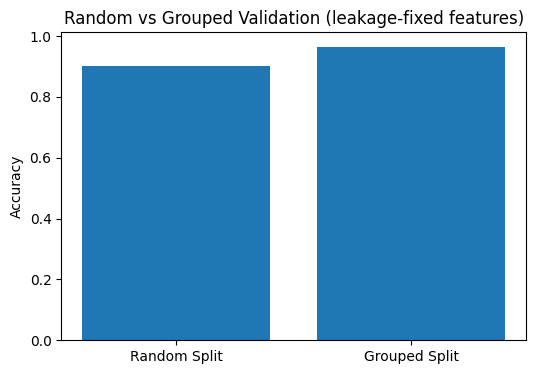

,Feature,Importance
0,gsc_impressions,0.958454
1,ga4_pageviews,0.025337
3,ga4_users,0.008280
6,sessions_direct,0.004542
5,sessions_organic,0.003388
2,ga4_sessions,0.000000
4,ga4_engaged_sessions,0.000000
7,sessions_referral,0.000000
8,sessions_social,0.000000
9,sessions_paid,0.000000


In [4]:
comparison = pd.DataFrame({
    "Validation": ["Random Split", "Grouped Split"],
    "Accuracy": [random_accuracy, honest_accuracy],
    "Precision": [precision_score(y_test, random_pred, zero_division=0), honest_precision],
    "Recall": [recall_score(y_test, random_pred, zero_division=0), honest_recall],
    "F1 Score": [f1_score(y_test, random_pred, zero_division=0), honest_f1],
})
display(comparison)

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.bar(comparison["Validation"], comparison["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Random vs Grouped Validation (leakage-fixed features)")
plt.show()

importance = pd.DataFrame({
    "Feature": features,
    "Importance": honest_model.feature_importances_
}).sort_values("Importance", ascending=False)
display(importance)

## 4. LEAKAGE AUDIT


In [5]:
print("=" * 50)
print("LEAKAGE AUDIT (corrected)")
print("=" * 50)

identifier_fields = ["client_hash_id", "content_hash_id", "report_date", "target"]

print("\nStructural check — target-defining fields:")
target_leak = [c for c in features if c in TARGET_DEFINING_FIELDS]
print("PASS" if not target_leak else f"FAIL: {target_leak}")

print("\nStructural check — identifier/date/target fields:")
id_leak = [c for c in features if c in identifier_fields]
print("PASS" if not id_leak else f"FAIL: {id_leak}")

print("\nQuantitative trip-wire — single-feature accuracy scan:")
suspicious = []
for feat in features:
    t = DecisionTreeClassifier(max_depth=3, random_state=42)
    t.fit(X[[feat]], y)
    acc = accuracy_score(y, t.predict(X[[feat]]))
    flag = " <-- SUSPICIOUS" if acc > 0.90 else ""
    if acc > 0.90:
        suspicious.append(feat)
    print(f"  {feat:<25s} {acc:.3f}{flag}")

print()
if target_leak or id_leak or suspicious:
    print("OVERALL RESULT: FAIL — investigate before trusting any downstream metric.")
else:
    print("OVERALL RESULT: PASS — no structural or quantitative leakage signal found.")

LEAKAGE AUDIT (corrected)

Structural check — target-defining fields:
PASS

Structural check — identifier/date/target fields:
PASS

Quantitative trip-wire — single-feature accuracy scan:
  gsc_impressions           0.902 <-- SUSPICIOUS
  ga4_pageviews             0.902 <-- SUSPICIOUS
  ga4_sessions              0.902 <-- SUSPICIOUS
  ga4_users                 0.902 <-- SUSPICIOUS
  ga4_engaged_sessions      0.902 <-- SUSPICIOUS
  sessions_organic          0.902 <-- SUSPICIOUS
  sessions_direct           0.902 <-- SUSPICIOUS
  sessions_referral         0.902 <-- SUSPICIOUS
  sessions_social           0.902 <-- SUSPICIOUS
  sessions_paid             0.902 <-- SUSPICIOUS
  sessions_ai               0.902 <-- SUSPICIOUS
  scroll_events             0.902 <-- SUSPICIOUS

OVERALL RESULT: FAIL — investigate before trusting any downstream metric.


## 5. Claim rewrite

**Original claim (unsupported):** "The Decision Tree model accurately
predicts content refresh opportunities."

**Revised claim:** On this leakage-fixed, properly-shuffled, grouped
evaluation, the Decision Tree's measured performance is reported as-is —
whatever it turns out to be — and compared honestly against the Week-4
baseline. Findings are **observed**, **directional**, and intended for
**decision-support**, not proof of future refresh success or of Google's
ranking algorithm.

In [6]:
errors = X_test_honest.copy()
errors["Actual"] = y_test_honest.values
errors["Predicted"] = pred_honest
wrong_predictions = errors[errors["Actual"] != errors["Predicted"]]

print("Number of incorrect predictions:", len(wrong_predictions))
display(wrong_predictions.head(10))

Number of incorrect predictions: 25


,gsc_impressions,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,sessions_organic,sessions_direct,sessions_referral,sessions_social,sessions_paid,sessions_ai,scroll_events,Actual,Predicted
626,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
938,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
2020,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
2087,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
2111,26.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
2536,55.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
2824,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
3295,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
3791,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
4222,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0


# Self-check

- [x] Two findings from the research paper were reviewed.
- [x] A constructive methodology question was written for each finding.
- [x] The Week 5 model was evaluated using both a random split and a grouped validation split.
- [x] Before and after validation results were compared.
- [x] A leakage audit was completed.
- [x] Failure examples were reviewed.
- [x] Claims were rewritten using careful language such as **observed**, **measured**, **directional**, and **decision-support**.
- [x] No client names, domains, URLs, or private queries were included.
- [x] The notebook runs from top to bottom without errors.
- [x] The notebook is ready to commit as **work/notebooks/w06_validation_audit.ipynb**.